<a href="https://colab.research.google.com/github/Eliezer-Carvalho/Tiny-GPT/blob/main/Tiny_GPT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Tiny-GPT**

Este modelo é baseado na arquitetura <b> Transformer </b>, inspirado nos modelos do tipo <b> GPT (<i>Generative Pre-trained Transformer</i>)</b>. <br>

Ao longo deste Colab, iremos navegar pelas componentes cruciais dos modelos GPT-like, que atualmente dominam grande parte do mundo da Inteligência Artificial.

<b> No final, teremos um modelo funcional no estilo GPT, capaz de realizar inferência. <br>
No entanto, é importante ter em conta que modelos desta dimensão apresentam limitações na geração de texto com consistência lexical. <br> </b>

Este Colab é extensão de um outro colab [Transformer - Attention Is All You Need](https://github.com/Eliezer-Carvalho/Tiny-GPT/blob/main/Transformer%20-%20Attention%20Is%20All%20You%20Need.ipynb) que faz parte do rep [Tiny-GPT](https://github.com/Eliezer-Carvalho/Tiny-GPT). <br>
Todas as diferenças entre ambos os colabs estarão marcadas com uma ⭐.


In [1]:
!wget https://raw.githubusercontent.com/Eliezer-Carvalho/Tiny-GPT/refs/heads/main/data/Os%20Lusiadas.txt

--2026-05-17 14:27:59--  https://raw.githubusercontent.com/Eliezer-Carvalho/Tiny-GPT/refs/heads/main/data/Os%20Lusiadas.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 321644 (314K) [text/plain]
Saving to: ‘Os Lusiadas.txt’

Os Lusiadas.txt     100%[===================>] 314.11K  --.-KB/s    in 0.003s  

2026-05-17 14:28:00 (106 MB/s) - ‘Os Lusiadas.txt’ saved [321644/321644]



### **Libraries**

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

device = "cuda" if torch.cuda.is_available() else "cpu" #Modelos LLM rodam em GPU e não em CPU
print (device)

cuda


###


---

### **Estatísticas do Dataset**

In [3]:
import re   #https://pypi.org/project/regex/

with open ("Os Lusiadas.txt", "r", encoding = "utf-8") as f:
  dataset = f.read()

#https://regexbox.com/cheatsheet
print (f"Caractéres --> {len(dataset)}")
print (f"Palavras --> {len(re.findall(r'\w+', dataset))}")
print (f"Linhas --> {len(re.findall(r'\n', dataset))}")

Caractéres --> 314636
Palavras --> 55825
Linhas --> 9940


###


---

### **Char Level Tokenizer**

No repositório que acompanha este projeto, [Transformer - Attention Is All You Need](https://github.com/Eliezer-Carvalho/Tiny-GPT/blob/main/Transformer%20-%20Attention%20Is%20All%20You%20Need.ipynb), foi realizado um estudo de diferentes Tokenizers num dataset distinto, tanto em termos de linguagem quanto de tamanho. <br>

O dataset utilizado neste repositório atual é relativamente pequeno <b>(315KB)</b>. A partir do estudo acima mencionado e alguns testes com modelos treinados, concluiu-se que algoritmos tradicionais de tokenização, como <b>BPE</b> ou <b>Unigram</b>, não são ideais para datasets pequenos. <br>

Isto ocorre porque os modelos Transformers necessitam de grandes quantidades de tokens para gerar texto de forma <b>lexical e semanticamente consistente</b>. <br>

Para se ter um exemplo, o primeiro modelo GPT lançado em 2018 juntamente com o paper <b>[Improving Language Understanding
by Generative Pre-Training](https://cdn.openai.com/research-covers/language-unsupervised/language_understanding_paper.pdf)</b> foi treinado com aproximadamente <b> 5 biliões de Tokens!!</b> <br>

Tendo um dataset pequeno, a idea é maximizar ao máximo o nível de Tokens. <br>
<b> Para tal, aplicamos um Character-Level Tokenizer </b>

In [4]:
#https://www.youtube.com/watch?v=kCc8FmEb1nY&t=6141s #Código proveniente deste vídeo

chars = sorted(list(set(dataset))) #Vocab_Size #Número de Tokens Únicos

numerate = {char:i for i, char in enumerate(chars)}
itos = {i:char for i, char in enumerate(chars)}

encode = lambda s: [numerate[c] for c in s]
decode = lambda l: ''.join([itos[i] for i in l])

print (f"Vocab_Size -> {len(chars)}")
print (f"Encoder -> {encode("Os Lusiadas são fixes!")}")
print (f"Decoder -> {decode(encode("Os Lusiadas são fixes!"))}")

Vocab_Size -> 85
Encoder -> [26, 55, 1, 23, 57, 55, 46, 38, 41, 38, 55, 1, 55, 72, 51, 1, 43, 46, 59, 42, 55, 2]
Decoder -> Os Lusiadas são fixes!


###


---

### **Tokenização**


In [5]:
dataset_tokenizado = encode(dataset)

print (dataset [36:103], "\n")
print (dataset_tokenizado [36:103], "\n")

print (f"Tiny-GPT é alimentado por {len(dataset_tokenizado)} Tokens!")

Que da ocidental praia Lusitana,
Por mares nunca de antes navegados 

[28, 57, 42, 1, 41, 38, 1, 51, 40, 46, 41, 42, 50, 56, 38, 48, 1, 52, 54, 38, 46, 38, 1, 23, 57, 55, 46, 56, 38, 50, 38, 7, 0, 27, 51, 54, 1, 49, 38, 54, 42, 55, 1, 50, 57, 50, 40, 38, 1, 41, 42, 1, 38, 50, 56, 42, 55, 1, 50, 38, 58, 42, 44, 38, 41, 51, 55] 

Tiny-GPT é alimentado por 314636 Tokens!


###


---

### **Tensor**

In [6]:
tensor = torch.tensor (dataset_tokenizado, dtype = torch.long) #https://docs.pytorch.org/docs/2.11/tensor_attributes.html #Importante perceber os tipos de dados possíveis

print (tensor.dtype)
print (tensor.shape)
print (tensor [:100])

torch.int64
torch.Size([314636])
tensor([ 0,  0, 13, 55,  1, 38, 54, 49, 38, 55,  1, 42,  1, 51, 55,  1, 39, 38,
        54, 81, 42, 55,  1, 38, 55, 55, 46, 50, 38, 48, 38, 41, 51, 55,  7,  0,
        28, 57, 42,  1, 41, 38,  1, 51, 40, 46, 41, 42, 50, 56, 38, 48,  1, 52,
        54, 38, 46, 38,  1, 23, 57, 55, 46, 56, 38, 50, 38,  7,  0, 27, 51, 54,
         1, 49, 38, 54, 42, 55,  1, 50, 57, 50, 40, 38,  1, 41, 42,  1, 38, 50,
        56, 42, 55,  1, 50, 38, 58, 42, 44, 38])


###


---

### **Dados de Treino e Dados de Validação**

<b> Atenção a esta fase </b> <br>
Importante para mais tarde treinar e avaliar o modelo!

In [7]:
data = int (0.9 * (len(tensor)))
train = tensor [:data] #90% Dados de Treino
val = tensor [data:] #10% Dados de Validação ou Teste

###


---

### **Batch e Sequence Length**

Importante, pois o modelo não recebe todos os Tokens de uma vez só, vai recebendo excertos.

In [8]:
torch.manual_seed (2000) #Número random para determinar uma posição random

def Batch (datatype):

  dados = train if datatype == 'train' else val #Posteriormente no treino vai ser importante para testar o modelo com dados de treino e com dados de teste

  indice = torch.randint (0, len(dados) - Sequence_Length, (Batch_Size, ))
  train_data = torch.stack ([dados [i: i + Sequence_Length] for i in indice]) #x são os dados que vão entrar no modelo
  val_data = torch.stack ([dados [i + 1: i + Sequence_Length + 1] for i in indice]) #y são os dados que mais tarde no treino vão ser necessários para calcular a loss

  train_data, val_data = train_data.to(device), val_data.to(device) #Passar os dados para a GPU, se o modelo corre na GPU, os dados têm de estar lá #IMPORTANTE

  return train_data, val_data

###


---



### **Definição de uma Head**

Uma Head não é nada mais nada menos do que a aplicação do mecanismo <b> Attention</b>.

$$
{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V
$$

<p align = "center">
  <img src = "https://machinelearningmastery.com/wp-content/uploads/2021/09/tour_3.png" width = 250>
</p>



A <b> Head Size (tamanho da cabeça)</b> representa o profundidade que uma Single Head irá ter. <br>
Ou seja, cada head não “vê” a sequência inteira do embedding diretamente. <br>
Transforma os embeddings para um espaço mais pequeno (<b>head_size</b>), onde aprende relações diferentes. <br>

Desta maneira cada head aprende padrões diferentes (ex: sintático, semântico, posição, etc.)

$$
head{size} = \frac{d_{emb}}{heads}
$$

In [9]:
class Head (nn.Module): #Head = Self Masked Attention
  def __init__(self):
    super().__init__()

    self.Query = nn.Linear (Embedding_Dimension, Head_Size, bias = False) #Isto é praticamente uma MLP sem bias #Query
    self.Key = nn.Linear (Embedding_Dimension, Head_Size, bias = False) #Isto é praticamente uma MLP sem bias #Key
    self.Value = nn.Linear (Embedding_Dimension, Head_Size, bias = False) #Isto é praticamente uma MLP sem bias #Value

    self.register_buffer('tril', torch.tril(torch.ones(Sequence_Length, Sequence_Length)))
    #Melhor assim, ao não criar sempre mask, a mask deixa de ser um parâmetro treinável, o que ajuda na computação do modelo
    #register_buffer faz isto "Guarda este tensor dentro do modelo, mas ele NÃO é um parâmetro treinável."
    #tril = triangular lower

    self.Dropout = nn.Dropout (0.2) #Dropout é importante para evitar overfitting

  def forward (self, x):

    B, T, C = x.shape

    Q = self.Query (x)
    K = self.Key (x)
    V = self.Value (x)

    # Scaled Dot-Product Attention
    attention_score = Q @ K.transpose (-2, -1) * (Head_Size ** -0.5) #Raiz de head_size é usado para normalizar os valores, se não, mais tarde softmax iria normalizar para valores maiores

    #Self Masked Attention
    attention_score = attention_score.masked_fill (self.tril [:T, :T] == 0, float ("-inf")) #Self Masked Attention

    #Softmax converte em probs
    attention_score = F.softmax (attention_score, dim = -1) #Normalização da attention_score

    #Dropout para evitar overfitting
    attention_score = self.Dropout (attention_score) #Evitar overfitting

    head_output = attention_score @ V
    return head_output

###


---


### **Definição de Multi Head** ⭐

É um dos conceitos mais simples e importantes dentro da arquitetura GPT.

Consiste em concatenar os outputs de várias <b> <i> heads (cabeças de atenção) </i> </b> e, em seguida, aplicar uma <i> <b> output projection </b> </i> para combinar e misturar a informação obtida.

As <b> Multi-Heads </b> permitem que o modelo capte diferentes tipos de relações dentro de uma sequência <b> (Sequence Length)</b>, analisando-a sob múltiplas perspetivas em simultâneo.

$$
{MultiHead}(Q, K, V) = \text{Concat}(\text{head}_1, \dots, \text{head}_h) W^O
$$

$$
{head}_i = \text{Attention}(QW_i^Q, KW_i^K, VW_i^V)
$$

<p align = "center">
  <img src = "https://www.jeremyjordan.me/content/images/size/w1000/2023/05/multi-head-attention.png" width = "600">
</p>

In [10]:
class Multi_Head (nn.Module):
  def __init__(self):
    super().__init__()

    self.Concat = nn.ModuleList ([Head() for i in range (Number_Head)]) #Head Concatenation #Definição de Multi Head Attention #Concat o output do Número de Heads
    self.Output_Projection = nn.Linear (Embedding_Dimension, Embedding_Dimension) #Necessário para misturar a informação das Heads #Desta forma volta também à dimensão (B, T, C)
    self.Dropout = nn.Dropout (0.2) #Dropout é importante para evitar overfitting

  def forward (self, x):

    output = self.Output_Projection (torch.cat ([f (x) for f in self.Concat], dim = -1))
    multi_head_output = self.Dropout(output)
    return multi_head_output

###


---


### **Definição de um Block ([Pre-LayerNorm Transformer](https://medium.com/@ashutoshs81127/why-pre-norm-became-the-default-in-transformers-4229047e2620))** ⭐

Com o paper <i> “Attention Is All You Need”</i>, foi introduzida a arquitetura Transformer, originalmente com uma abordagem chamada <b> Post-Norm</b>. <br>
No entanto, rapidamente os investigadores identificaram problemas ao escalar modelos mais profundos, como:

- <b> Treino instável em redes profundas </b>
- <b> Gradientes a explodir ou a desaparecer </b>

Isto levou ao surgimento da abordagem <b> Pre-Norm</b>, que melhorou significativamente a estabilidade do treino.
<br>
<br>
#### <b> Post-Norm vs Pre-Norm ? </b>

- <b>Abordagem Post-Norm:</b>

<i> Attention -> Add -> Norm -> Feed Forward -> Add -> Norm</i>

- <b>Abordagem Pre-Norm:</b>

<i> Norm -> Attention -> Add -> Norm -> Feed Forward -> Add </i>

<br>

Nos modelos atuais, o bloco típico é <b> Pre-Norm</b>, e a ordem correta é:
<b>
- Layer Norm
- Multi-Head Self-Attention
- Residual Connection (Add)
- Layer Norm
- Feed Forward Neural Network (MLP)
- Residual Connection (Add)
</b>

Estes métodos conjugados é aquilo a que chamamos de <b> Block </b> ou <b> Layer</b>.
<br>

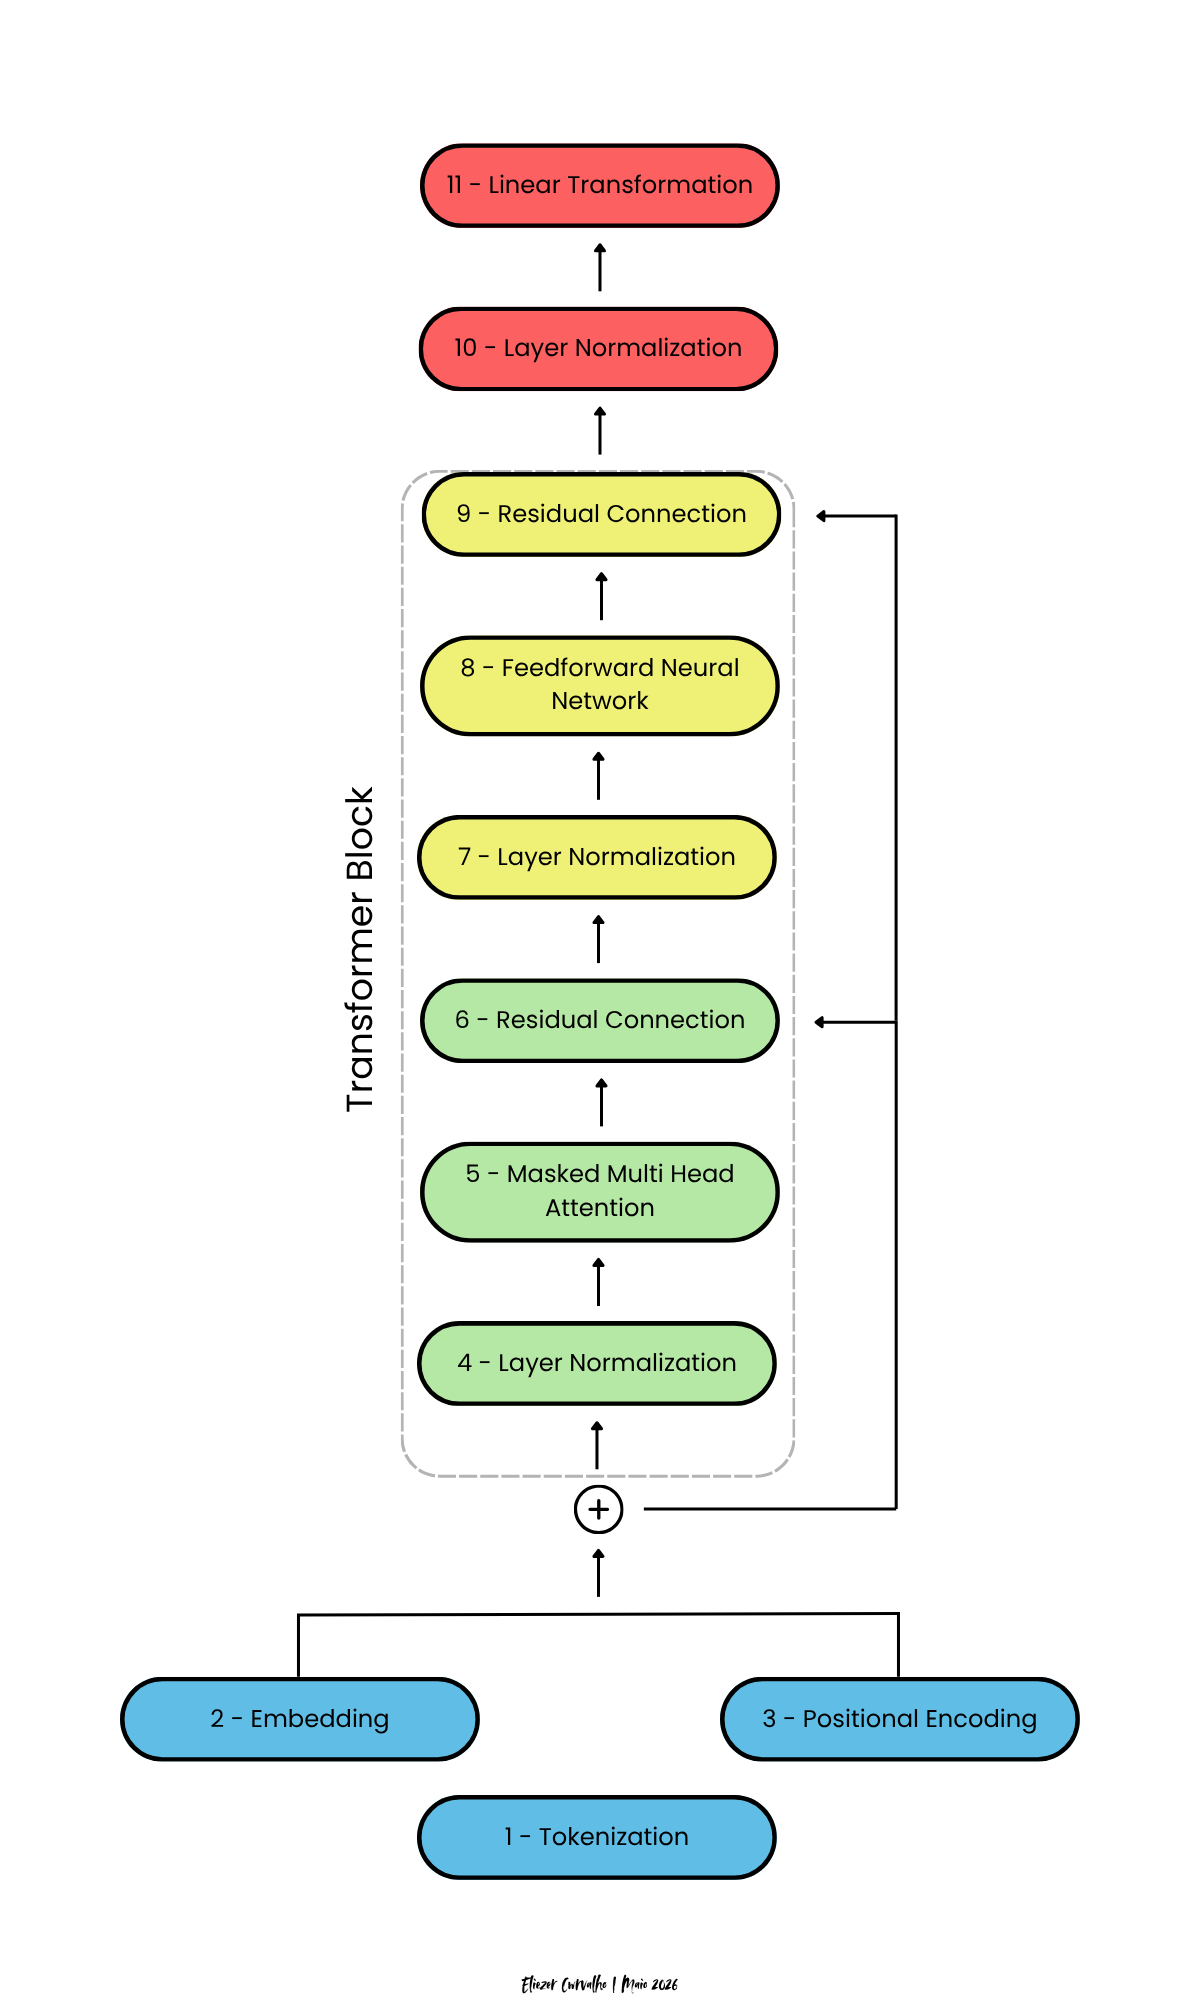

In [11]:
class Block (nn.Module):
  def __init__(self):
    super().__init__()

    self.LayerNorm_Attention = nn.LayerNorm (Embedding_Dimension) #Layer Norm amtes da Attention
    self.Masked_Multi_Head_Attention = Multi_Head() #Self Masked Attention


    self.LayerNorm_FNN = nn.LayerNorm (Embedding_Dimension) #Layer Norm antes da MLP
    self.FeedForward_NeuralNet = nn.Sequential ( #MLP
        nn.Linear (Embedding_Dimension, 4 * Embedding_Dimension), #*4 está no paper original
        nn.GELU(),
        nn.Linear (Embedding_Dimension * 4, Embedding_Dimension),
        nn.Dropout (0.2) #Dropout é importante para evitar overfitting
    )


  def forward (self, x):
    Norm_Attention = self.Masked_Multi_Head_Attention (self.LayerNorm_Attention (x)) #Norm #LayerNorm
    Add_Attention = x + Norm_Attention #Add #Residual Connection #Muito Importante!!!
    x = Add_Attention

    Norm_FNN = self.FeedForward_NeuralNet (self.LayerNorm_FNN (x)) #Norm #LayerNorm
    Add_FNN = x + Norm_FNN #Add #Residual Connection #Muito Importante!!!
    x = Add_FNN

    return x

###


---


### **Modelo Tiny-GPT** ⭐

<i> Implementação do Modelo Final </i>

In [12]:
class TINY_GPT (nn.Module):
  def __init__(self):
    super().__init__()

    self.Embedding = nn.Embedding (len(chars), Embedding_Dimension) #Embedding dos Tokens
    self.Positional_Encoding = nn.Embedding (Sequence_Length, Embedding_Dimension) #Positional Encoding dos Tokens

    self.Blocks = nn.Sequential ( #Não é a maneira ideal de se fazer. #Atenção ao mudar o número de Blocks
        Block(),
        Block(),
        Block(),
        Block(),
    )

    self.LayerNorm = nn.LayerNorm(Embedding_Dimension) #Layer Norm antes do Language Modelling #Presente no paper
    self.Language_Modeling = nn.Linear (Embedding_Dimension, len(chars)) #Converte o vetor final do modelo em logits sobre o vocabulário inteiro.

  def forward (self, x):
    B, T = x.shape

    x = self.Embedding (x) + self.Positional_Encoding (torch.arange (T, device = x.device))

    x = self.Blocks(x)

    x = self.LayerNorm (x)

    logits = self.Language_Modeling(x)

    return logits #Return de um tensor (B, T, VOCAB_SIZE)

###


---


### **Treino do Modelo (Super-Importante)** ⭐

<b> Como já vimos no código, os pesos são iniciados de forma aleatória.</b> <br>
Assim, é essencial um <b> processo de treino</b>, que permita atualizar estes parâmetros iterativamente com base no erro do modelo, tornando-o progressivamente mais preciso.


Para treinar estes parâmetros, é necessário um processo de otimização baseado em <b>gradientes</b>. <br>
O modelo faz previsões e compara-as com os valores reais através de uma função de perda <i>(loss function)</i>. <br>
<br>

Uma das funções de perda mais utilizadas em problemas de linguagem é a <b> <i> Cross Entropy Loss</b></i>, que penaliza o modelo quando atribui baixa probabilidade à resposta correta. <br>
Em tarefas de linguagem, isto é essencial porque o objetivo é maximizar a probabilidade do próximo token correto. <br>
<br>

Depois de calcular a <i>loss</i>, utilizamos o processo de backpropagation para determinar os <b> Gradientes.</b> <br>
Os Gradientes representam a direção e a magnitude com que cada peso da rede deve ser ajustado para minimizar o erro. <br>
Em termos simples, indicam como cada parâmetro influencia o resultado final e como deve ser alterado para melhorar a performance do modelo.
<br>
<br>
Os gradientes por si só não atualizam os pesos! <br>
Essa tarefa é realizada pelos <b> Otimizadores</b>, que utilizam os gradientes para aplicar correções aos parâmetros de forma eficiente e estável. <br>
Em vez de simplesmente ajustar os pesos diretamente com base no erro, os otimizadores definem a melhor forma de os atualizar ao longo do tempo, tendo em conta fatores como a taxa de aprendizagem e o comportamento histórico dos gradientes. <br>
Entre os otimizadores mais utilizados estão o SGD (*Stochastic Gradient Descent*), o Adam e o AdamW.

<br>
<br>

<b> Resumo:</b> <br>
O treino de uma arquitetura Transformer segue este ciclo:
<b>
- Forward pass (previsão do modelo)
- Cálculo da Cross Entropy Loss
- Backpropagation (cálculo dos gradientes)
- Otimizador atualiza os pesos
- Repetição até o modelo convergir
</b>

#### Função que Treina o modelo

In [13]:
def Training (modelo, steps):

  train_losses = []
  val_losses = []

  modelo.train() #Ativa o treino #https://docs.pytorch.org/tutorials/beginner/introyt/trainingyt.html

  for i in range (steps):

    x, y = Batch('train') #(B, T) #Dados de Treino

    logits = modelo (x) #Passa os dados x pelo modelo
    #print (logits.shape)
    B, T, V = logits.shape #(Batch, Sequence Length, Vocab_Size)

    #Cross Entropy vai determinar a diferença entre o token escolhido (x) e o certo (y)
    loss = loss_function (logits.view (B * T, V), y.view (B * T)) #Entrada que Cross Entropy espera, passamos os valores que o modelo cuspiu e comparamos com os dados de validação.
    #O que a loss function faz é como se fosse um aluno que responde a uma pergunta (advinha o próximo token) e depois vai ver se está correto (dados_val)

    optimizer.zero_grad() #Zera os gradientes acumulados nos parâmetros. #Necessário a cada passo para não acumular gradientes
    loss.backward() #Após calcular o erro, o backprop passa pelos pesos todos da rede e calcula o gradiente do peso em relação à loss

    optimizer.step() #Optimizer aplicado #O optimizer é o que muda o valor dos pesos

    if i % 1000 == 0: #Printa de 1000 em 1000

      losses = Calc_Loss (modelo)

      train_losses.append(losses["train"])
      val_losses.append(losses["val"])

      print(f"Step {i} | Train Loss: {losses['train']:.4f} | Validation Loss: {losses['val']:.4f} | Perplexity Loss: {math.exp(loss.item()):.4f}") #Perplexity indica o nível de confiança que o modelo tem na sua previsão

  return train_losses, val_losses

#### Calcular a Loss

Esta função foi altamente influenciada por este rep -> [nanoGPT](#https://github.com/karpathy/nanoGPT/blob/master/train.py)

In [14]:
#https://github.com/karpathy/nanoGPT/blob/master/train.py

#Esta função é muito parecida com a do treino, porém, usa dados de validação para calcular a loss, pois o modelo no cálculo da loss, não pode ver os dados de treino
@torch.no_grad() #Desliga o cálculo dos gradientes, importante em termos computacionais
def Calc_Loss (modelo, loop_eval = 500):

    output = {}
    modelo.eval() #Desliga modo de treino

    for split in ['train', 'val']: #Calcula a loss para os conjuntos de treino e validação
        losses = torch.zeros (loop_eval) #Cria um tensor com int "0" com tamanho loop_eval

        for i in range (loop_eval): #Por cada loop_eval o modelo vai ser alimentado por um novo batch de dados e vai ser testado a sua habilidade tanto em dados de teste como em dados de validação

            x, y = Batch (val) #Quando for train:                         #Quando for outro nome qualquer:
            logits = modelo (x) #Alimenta o modelo com dados de treino      #Alimenta o modelo com dados de teste/val

            B, T, V = logits.shape

            loss = loss_function (logits.view (B * T, V), y.view (B * T))
            losses[i] = loss.item() #Armazena as losses no tensor

        output[split] = losses.mean() #Calcula a média, mais preciso

    modelo.train() #Volto ao modo de treino
    return output

### **Tiny-GPT Treino**

Só para ter noção, o modelo base apresentado pelo paper *Attention Is All You Need* foi treinado com 100k steps. :)

In [15]:
#modelo = TINY_GPT().to(device) #GPU

#optimizer = torch.optim.AdamW (modelo.parameters(), lr = 3e-4) #Usa-se AdamW ou SGD #Responsável por atualizar os pesos do modelo
#loss_function = nn.CrossEntropyLoss() #Função de perda que mede quão diferente está a previsão do modelo da resposta correta.

#Training (modelo, 5000)

###


---

### **Geração de Texto** ⭐

Esta função foi altamente influenciada por este rep -> [nanoGPT](#https://github.com/karpathy/nanoGPT/blob/master/train.py)

In [16]:
@torch.no_grad() #Desliga o cálculo de gradientes, torna a inferência mais rápida
def Model_Infer (modelo, max_tokens, indice, temperatura = 1, top_tokens = None):

  modelo.eval() #Desliga o treino

  for i in range (max_tokens): #Vai adicionando token a token

    indice_condition = indice [:, -Sequence_Length:] #Alimento o modelo com o os tokens que já tem ou que não tem para ele prever o próximo

    logits = modelo (indice_condition) #Aplicação da Arquitetura

    logits = logits [:, -1, :] / temperatura #Foca no que gerou anteriormente #Temperatura aumenta ou diminui a creatividade. Se > 1 há mais chance de tokens raros serem escolhidos

    #https://github.com/karpathy/nanoGPT/blob/master/model.py
    if top_tokens is not None: #TopK funciona como um limitador que ajuda o modelo a olhar para os tokens com  melhores probabilidades, em vez de olhar para todos
              V = torch.topk (logits, min(top_tokens, logits.size (-1))) #https://docs.pytorch.org/docs/2.11/generated/torch.topk.html
              logits [logits < V [:, [-1]]] = -float('Inf') #Substitui os tokens com menor probabilidade por -inf


    probs = F.softmax (logits, dim = -1) #Aplica Softmax para ter as probabilidades

    prev = torch.multinomial (probs, num_samples = 1) #Seleciona um token

    indice = torch.cat ((indice, prev), dim  = 1) #Adiciona esse token ao contexto

  return indice

### **Tiny-GPT Inferência**

In [17]:
#contexto = torch.zeros ((1, 1), dtype = torch.long, device = device) #Cria um tensor [1,1] com o valor 0 e à medida que entra na função vai adicionando tokens
#indice = Model_Infer (modelo, max_tokens = 500, indice = contexto)

#print (decode(indice[0].tolist()))

###


---

###


---

In [ ]:
import matplotlib.pyplot as plt

### **CPU vs GPU Perfomance de Treino**


<b> Modelo </b> <br>

*   Número de Parâmetros -> 250 000
*   Batch -> 8
*   Sequence_Length -> 64
*   Embedding_Dimension -> 64
*   Head_Size -> 8
*   Number_Head -> 8
*   Blocks -> 4

<b> Treino </b> <br>

*   Optimizer -> AdamW, lr = 0,0003
*   Função de Loss -> CrossEntropyLoss

<b> Dados CPU e GPU </b>

*   CPU -> [AMD Ryzen 5 4500 6-Core Processor](https://www.techpowerup.com/cpu-specs/ryzen-5-4500.c2758)
*   GPU -> [T4 GPU](https://www.nvidia.com/en-us/data-center/tesla-t4/)


In [ ]:
model_CPU = torch.load("Modelo_CPU")
time_training_CPU = model_CPU["time_training"]

model_GPU = torch.load("Modelo_GPU", map_location = device)
time_training_GPU = model_GPU["time_training"]

pltt = {
    "CPU": time_training_CPU,
    "GPU": time_training_GPU
}

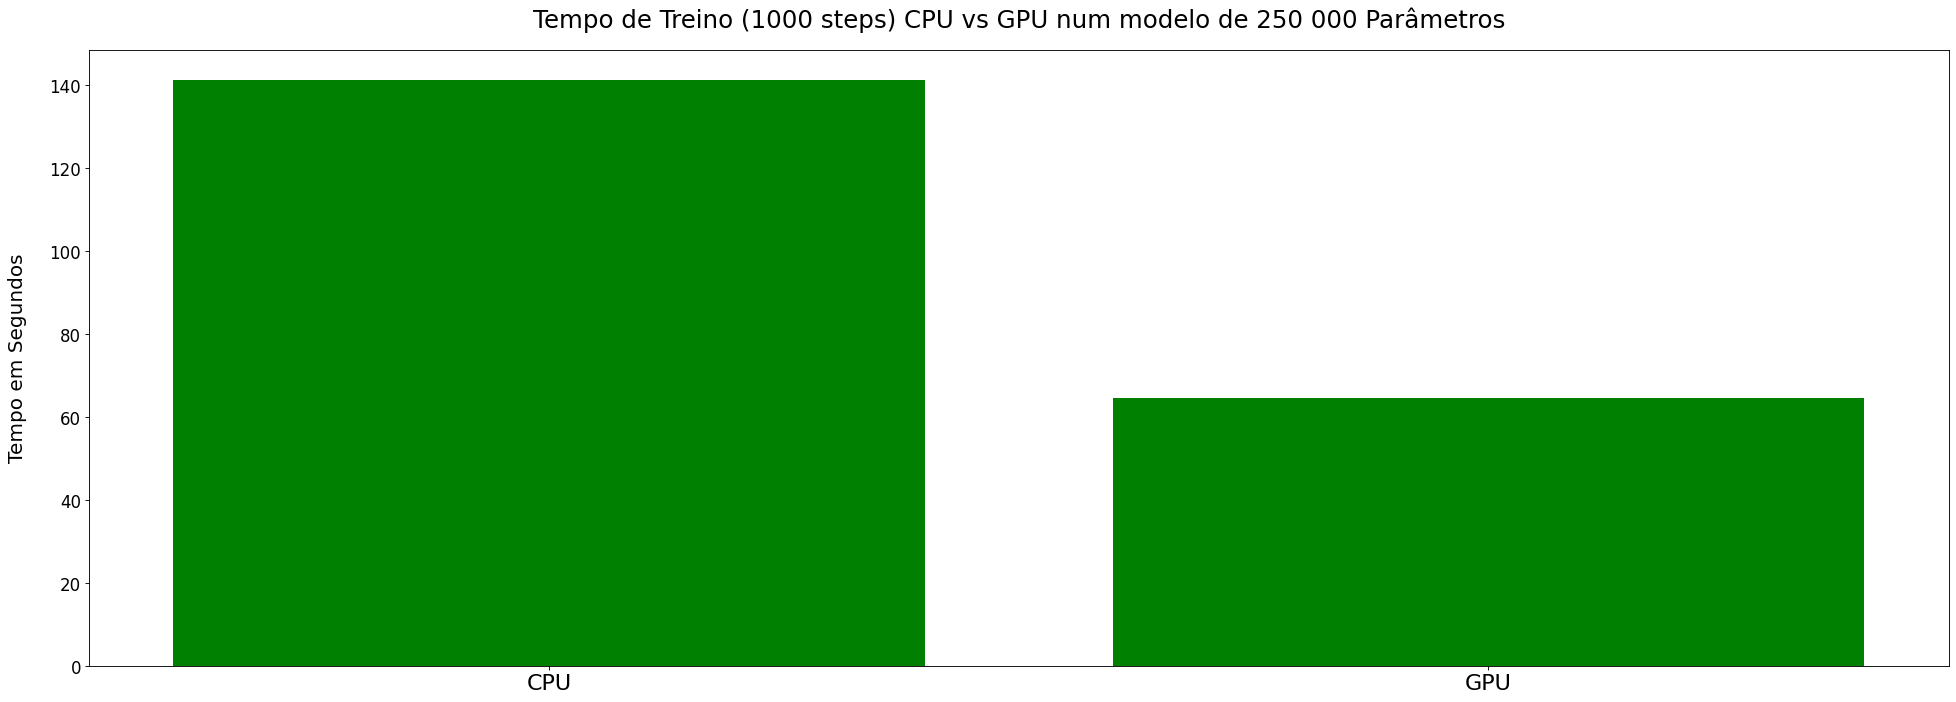

In [ ]:
plt.figure (figsize = (30, 10), dpi = 80)
plt.bar (pltt.keys(), pltt.values(), color = "green")

plt.xticks (size = 20)
plt.yticks (size = 15)
plt.ylabel ("Tempo em Segundos", size = 18, labelpad = 20)

plt.title ("Tempo de Treino (1000 steps) CPU vs GPU num modelo de 250 000 Parâmetros", size = 22, pad = 20)
plt.show()

###


---

### **Scaling Laws**



#### **[Kaplan Scaling Laws](https://arxiv.org/pdf/2001.08361)**

As <i> <b>Scaling Laws</b> </i> apresentadas pela OpenAI demonstraram empiricamente que aumentar a escala de treino de um modelo <b>(número de parâmetros, quantidade de tokens e poder computacional)</b> tende a torná-lo mais capaz e a melhorar a sua qualidade.

Em outras palavras, modelos maiores tendem a apresentar melhor desempenho, desde que exista também dados e compute suficientes para os treinar adequadamente.

Vamos ver se é verdade..



**Discussão**

Com este estudo, comprovou-se que é sim verdade. <br>
<b> Aumentar o número de Parâmetros de um Modelo torna-o efetivamente melhor!

In [ ]:
model_500k = torch.load("Modelo_500k")
train_loss_500k = model_500k["train loss"]
val_loss_500k = model_500k["val_loss"]

model_2M = torch.load("Modelo_2M")
train_loss_2M = model_2M["train loss"]
val_loss_2M = model_2M["val_loss"]

print (f"Train Loss 500k -> {train_loss_500k}")
print (f"Train Loss 2M -> {train_loss_2M}\n")

print (f"Val Loss 500k {val_loss_500k}")
print (f"Val loss 2M {val_loss_2M}")

Train Loss 500k -> [tensor(4.5448), tensor(2.3078), tensor(2.1986), tensor(2.1197), tensor(2.0510)]
Train Loss 2M -> [tensor(4.3285), tensor(2.1819), tensor(2.0208), tensor(1.9246), tensor(1.8526)]

Val Loss 500k [tensor(4.5451), tensor(2.3037), tensor(2.2029), tensor(2.1201), tensor(2.0492)]
Val loss 2M [tensor(4.3299), tensor(2.1779), tensor(2.0179), tensor(1.9288), tensor(1.8589)]


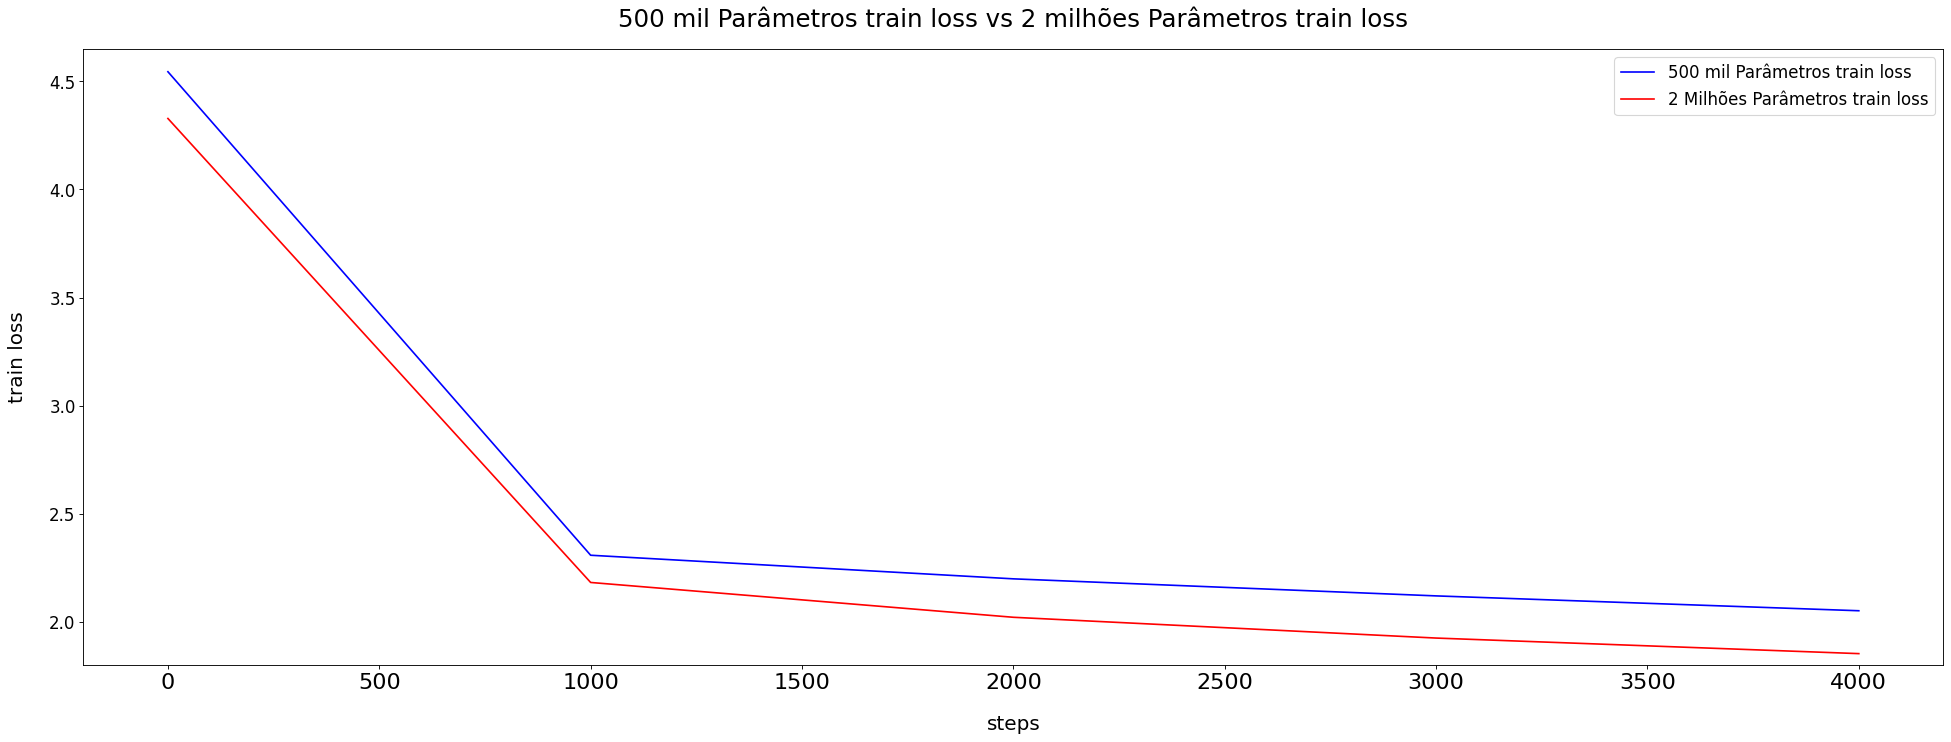

In [ ]:
plt.figure (figsize = (30, 10), dpi = 80)

plt.plot (list(range(0, 5000, 1000)), train_loss_500k, color = "blue", label = "cx")
plt.plot (list(range(0, 5000, 1000)), train_loss_2M, color = "red")
#plt.plot (list(range(0, 5000, 1000)), val_loss_500k, color = "green")
#plt.plot (list(range(0, 5000, 1000)), val_loss_2M, color = "red")

plt.xticks (size = 20)
plt.xlabel("steps (max = 5000)", size = 18, labelpad = 20)

plt.ylim(1.8000, 4.6500)
plt.yticks (size = 15)
plt.ylabel ("train loss", size = 18, labelpad = 20)

plt.legend(["500 mil Parâmetros train loss", "2 Milhões Parâmetros train loss"], fontsize = 15)
plt.title ("500 mil Parâmetros train loss vs 2 milhões Parâmetros train loss", size = 22, pad = 20)
plt.show()

In [ ]:
plt.figure (figsize = (30, 10), dpi = 80)

plt.plot (list(range(0, 5000, 1000)), val_loss_500k, color = "green")
plt.plot (list(range(0, 5000, 1000)), val_loss_2M, color = "black")

plt.xticks (size = 20)
plt.xlabel("steps", size = 18, labelpad = 20)

plt.ylim(1.8000, 4.6500)
plt.yticks (size = 15)
plt.ylabel ("val loss", size = 18, labelpad = 20)

plt.legend(["500 mil Parâmetros val loss", "2 Milhões Parâmetros val loss"], fontsize = 15)
plt.title ("500 mil Parâmetros val loss vs 2 milhões Parâmetros val loss", size = 22, pad = 20)
plt.show()

#### **[Chinchilla Scaling Laws](https://arxiv.org/pdf/2203.15556)**

As <i>  <b> Chinchilla Scaling Laws</i> </b>, apresentadas pela DeepMind, vieram refinar as Scaling Laws.

Este trabalho demonstrou empiricamente que, para um dado orçamento computacional, existe uma <b> relação ótima entre o número de parâmetros e a quantidade de tokens de treino</b>.

Em particular, mostrou-se que muitos modelos anteriores estavam sub-treinados (<i>undertrained</i>), pois utilizavam demasiados parâmetros relativamente à quantidade de dados.

Assim, em vez de apenas aumentar o tamanho do modelo, é mais eficiente equilibrar corretamente<b> Parâmetros e Dados </b> para maximizar a performance.<br>
Fórmula que o paper apresentou:

$$
{\text{Número de Tokens}} ≈ {20 * {\text{Número de Parâmetros}}}
$$

O primeiro GPT apresentado pela OpenAI em 2018, tinha <b>120 milhões de Parâmetros </b> e foi treinado com um corpus de <b>700 milhões de Tokens</b>. <br>
<b>De acordo com as Chinchilla Scaling Laws, o modelo estava claramente sub-treinado e a desperdiçar recursos computacionais. </b>

No meu caso em específico, que temos inicialmente um dataset definido, podemos trocar a fórmula e tentar chegar ao número ideal de parâmetros para o nosso modelo. <br>

$$
{\text{Número de Parâmetros}} ≈ {\frac{\text{Número de Tokens}}{20}}
$$

Vamos testar..

**Discussão**

Este estudo, comprovou que as Chinchilla Scaling Laws fazem sentido! <br>
<b> Aumentar o número de Parâmetros de um Modelo torna-o efetivamente melhor porém, quão melhor e a que custo ? </b> <br>

Como vimos nos gráficos, um modelo muito maior (3.5M de Parâmetros), realmente obteve valores de training loss e val loss melhores em relação ao modelo mais pequeno (20K Parâmetros) porém, a diferença não é assim tão significativa comparado com as diferenças de tamanho do modelo. <br>

<b> Vale lembrar que treinar um modelo maior, é mais caro e mais dispendioso em termos de tempo! </b><br>

Recomenda-se usar para produção um modelo superior em relação aos números de parâmetros que a fórmula dá. <br>

A ideia desta Law é como explicar que dentro de um avião, se colocarmos uma migalha até está tudo bem, porém, em termos de eficiência e combustível não será a melhor opção. <br>
Ao contrário, se para essa migalha usarmos um carro para a transportar, acaba por ficar mais eficiente e torna-se de maneira clara a melhor escolha. <br>

In [ ]:
tokens_count = len(tensor)
print (f"Número de Tokens -> {tokens_count}")
print (f"Número Ideal de Parâmetros -> {tokens_count // 20}")

Número de Tokens -> 314636
Número Ideal de Parâmetros -> 15731


In [ ]:
model_20k = torch.load("Modelo_20K")
train_loss_20k = model_20k["train_loss"]
val_loss_20k = model_20k["val_loss"]

model_3_5M = torch.load("Modelo_3.5M")
train_loss_3_5M = model_3_5M["train loss"]
val_loss_3_5M = model_3_5M["val_loss"]

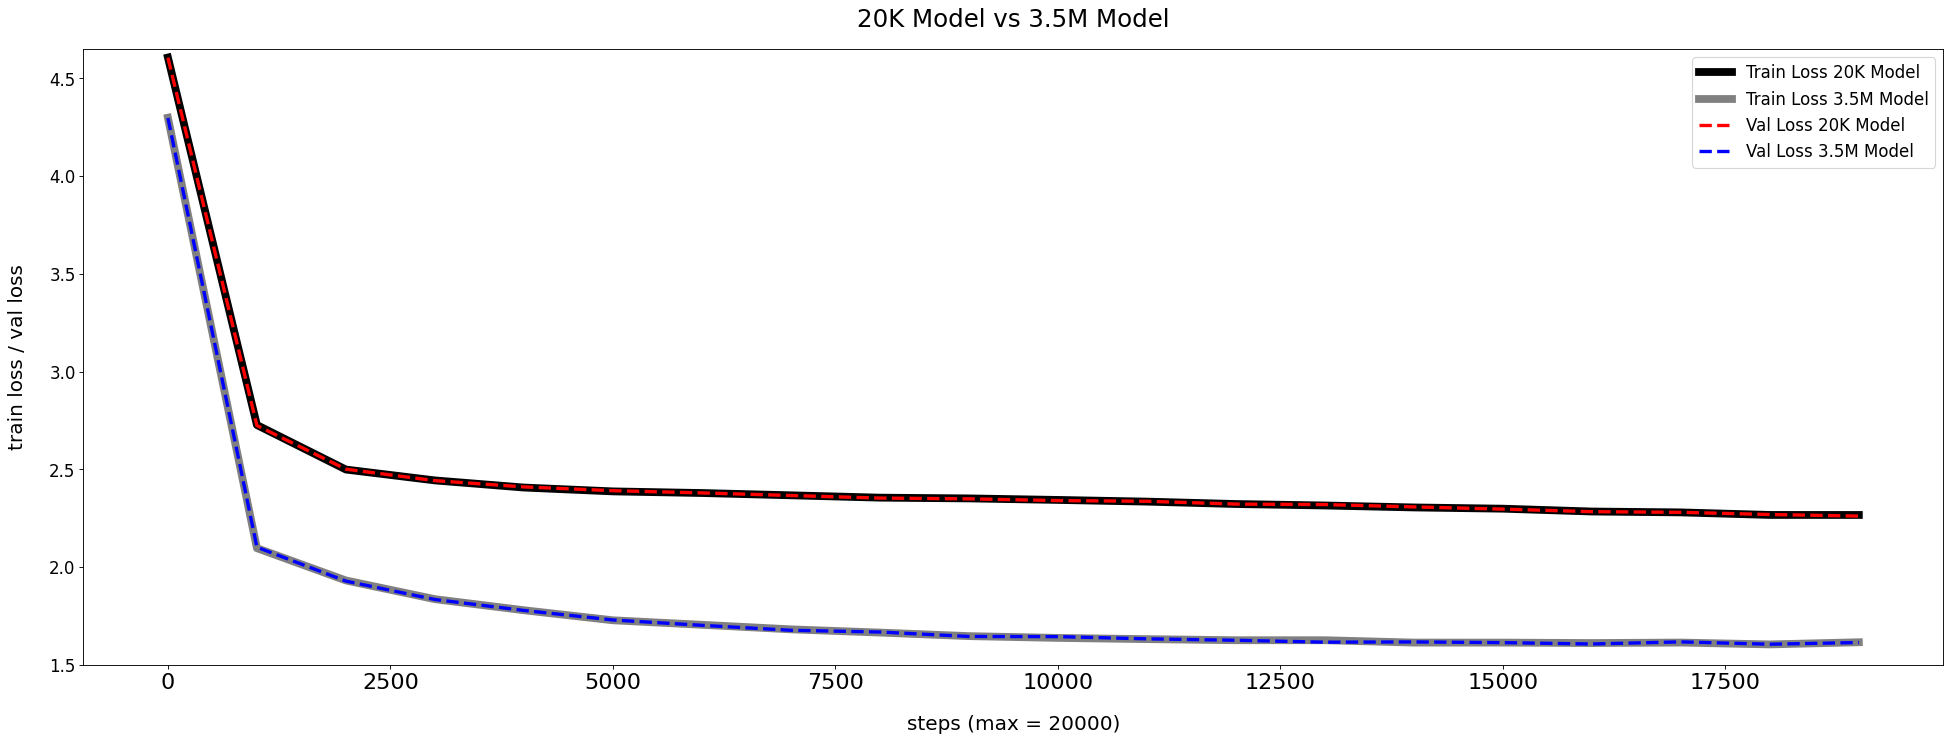

In [ ]:
plt.figure (figsize = (30, 10), dpi = 80)

plt.plot (list(range(0, 20000, 1000)), train_loss_20k, color = "black", lw = 7)
plt.plot (list(range(0, 20000, 1000)), train_loss_3_5M, color = "gray", lw = 7)
plt.plot (list(range(0, 20000, 1000)), val_loss_20k, color = "red", lw = 3, ls = '--')
plt.plot (list(range(0, 20000, 1000)), val_loss_3_5M, color = "blue", lw = 3, ls = '--')

plt.xticks (size = 20)
plt.xlabel("steps (max = 20000)", size = 18, labelpad = 20)

plt.ylim(1.5000, 4.6500)
plt.yticks (size = 15)
plt.ylabel ("train loss / val loss", size = 18, labelpad = 20)

plt.legend(["Train Loss 20K Model", "Train Loss 3.5M Model", "Val Loss 20K Model", "Val Loss 3.5M Model"], fontsize = 15)
plt.title ("20K Model vs 3.5M Model", size = 22, pad = 20)
plt.show()

###


---

### **Eficiência Computacional nos Transformers**

Os Transformers são arquiteturas que funcionam principalmente por multiplicação de matrizes. <br>
Por esse motivo, como já vimos, os modelos correm por norma em GPUs por estas apresentarem uma maior capacidade de pararelismo em relação ás CPUs. <br>

Um dos pontos mais importantes, é a <b> eficiência da GPU dado um x modelo</b>. <br>
Ou seja, eu posso ter uma GPU mas qual a <b>taxa de eficiência da minha GPU em relação ao meu modelo ? Estou a usar toda a capacidade da minha GPU ?</b> <br>

Para conseguir chegar a um bom resultado, é necessário introduzir dois pontos fundamentais:

*   <b>FLOPs</b> -> Número de Operações com Pontos Flutuantes realizadas por um modelo.
*   <b> MFU </b> -> Percentagem dos FLOPs teóricos máximos da GPU que estão efetivamente a ser utilizados pelo modelo durante o treino ou inferência.

<b> É preciso salientar que as GPUs têm uma enorme capacidade teórica mas um modelo raramente atinge a capacidade teórica total. <br>MFU mede essa eficiência real! </b>  



Algumas fórmulas importantes:

$
\text {FLOPs por Treino} ≈ \text {6 * Parâmetros Non Embedding * Tokens}
$
<br>
<br>
$
\text {FLOPs por Token} ≈ \text {2 * Parâmetros Non Embedding * Tokens}
$
<br>
<br>
$
\text {FLOPs por Inferência} ≈ \text {FLOPs por Token * Tokens}
$

Step 0 | Train Loss: 4.6928 | Validation Loss: 4.6897 | Perplexity Loss: 109.4492
7.311490058898926


## Código

In [ ]:
'''import time

#CÓDIGO ESTUDO CPU VS GPU

#Parâmetros do modelo

Batch_Size = 8
Sequence_Length = 64
Embedding_Dimension = 64
Head_Size = 8
Number_Head = 8
Blocks = 4

modelo_gpu = TINY_GPT().to(device) #CPU

optimizer = torch.optim.AdamW (modelo_gpu.parameters(), lr = 3e-4) #Usa-se AdamW ou SGD #Responsável por atualizar os pesos do modelo
loss_function = nn.CrossEntropyLoss() #Função de perda que mede quão diferente está a previsão do modelo da resposta correta.

start_time = time.time()
Training (modelo_gpu, 1000)
end_time = time.time()


torch.save({
    'modelo': modelo_gpu.state_dict(),
    'optimizer': optimizer.state_dict(),
    'time_training': end_time - start_time,
}, 'Modelo_GPU')


print (end_time - start_time)
print (sum(p.numel() for p in modelo_gpu.parameters()))
'''

Step 0 | Train Loss: 4.5418 | Validation Loss: 4.5393 | Perplexity Loss: 98.7293
64.63736462593079
214357


In [ ]:
'''
model = TINY_GPT().to(device)
optimizerr = torch.optim.AdamW (model_CPU.parameters(), lr = 2e-4)

checkpoint = torch.load ('f')

model.load_state_dict(checkpoint['modelo'])
optimizerr.load_state_dict(checkpoint['optimizer'])

training (model, 10000)
'''

In [ ]:
'''num_params = sum(p.numel() for p in model_CPU.parameters())
tam_na_gpu = num_params * 64

tam_na_gpu_train = tam_na_gpu * 4

print (num_params)
print (f"{tam_na_gpu:.0f} Bytes")
print (f"{tam_na_gpu_train:.0f} Bytes")
#save = torch.save(modelo.state_dict(), "Adamastor-GPT.pth")





print (modelo.state_dict())
for param in modelo.state_dict():
  print (param)
'''







In [ ]:
#Scaling Laws

'''
Batch_Size = 8
Sequence_Length = 64
Embedding_Dimension = 96
Head_Size = 12
Number_Head = 8
Blocks = 4


Batch_Size = 8
Sequence_Length = 64
Embedding_Dimension = 192
Head_Size = 12
Number_Head = 16
Blocks = 4

modelo_500k = TINY_GPT().to(device) #CPU ou GPU

optimizer = torch.optim.AdamW (modelo_500k.parameters(), lr = 3e-4) #Usa-se AdamW ou SGD #Responsável por atualizar os pesos do modelo
loss_function = nn.CrossEntropyLoss() #Função de perda que mede quão diferente está a previsão do modelo da resposta correta.

train_loss, val_loss = Training (modelo_500k, 5000)


torch.save({
    'modelo': modelo_500k.state_dict(),
    'optimizer': optimizer.state_dict(),
    'train loss': train_loss,
    'val_loss': val_loss
}, 'Modelo_500k')
'''

In [ ]:

'''
import time

Batch_Size = 8
Sequence_Length = 64
Embedding_Dimension = 16
Head_Size = 4
Number_Head = 4
Blocks = 4

modelo_teste_MFU = TINY_GPT().to(device) #CPU ou GPU

optimizer = torch.optim.AdamW (modelo_teste_MFU.parameters(), lr = 3e-4) #Usa-se AdamW ou SGD #Responsável por atualizar os pesos do modelo
loss_function = nn.CrossEntropyLoss() #Função de perda que mede quão diferente está a previsão do modelo da resposta correta.

torch.cuda.synchronize()
start = time.time()
Training (modelo_teste_MFU, 1)

torch.cuda.synchronize()
end = time.time()


tempo = end - start
print (tempo)
'''